# DS605: Fundamentals of Machine Learning

# Lab Assignment - 3

# Scikit-learn: Data Preprocessing and Model Performance Evaluation

Part A - Data Loading and Preprocessing with Scikit-learn
Task 1 - Load and Understand the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

print("First 5 rows:")
display(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())

print("\nClass Distribution (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]

X = df.drop(columns=["is_canceled"])

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Shape of dataset:
(119390, 32)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Data Types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                

C:\Users\gpala\AppData\Local\Temp\ipykernel_30580\279140545.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


## Task 2 - Missing Values, Leakage, and Outliers

### Finding the missing-value count and percentage for every column.

In [2]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_df)

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


### Removing columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.

In [3]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])

print("Dataset shape after removing leakage columns:")
print(df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after removing leakage columns:
(119390, 30)

Remaining columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


### Identifying outliers

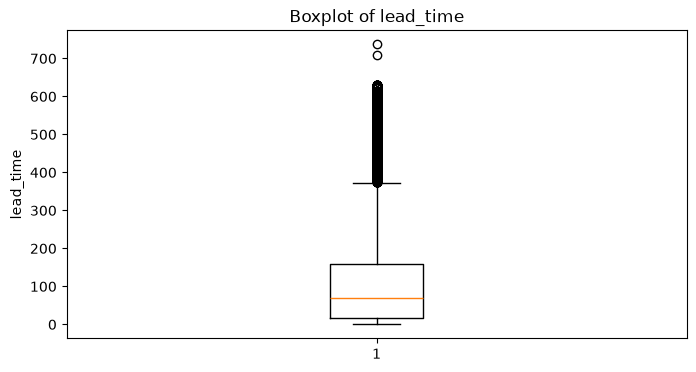

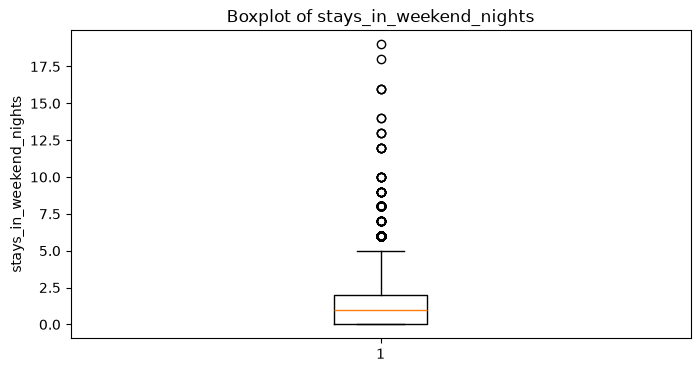

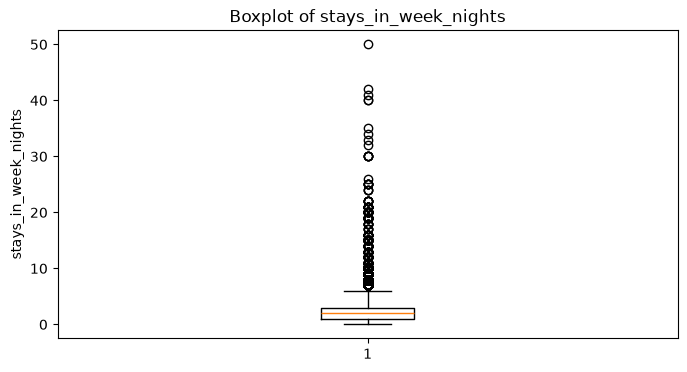

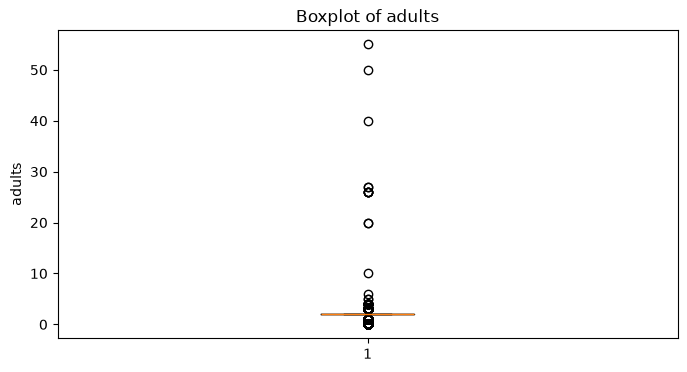

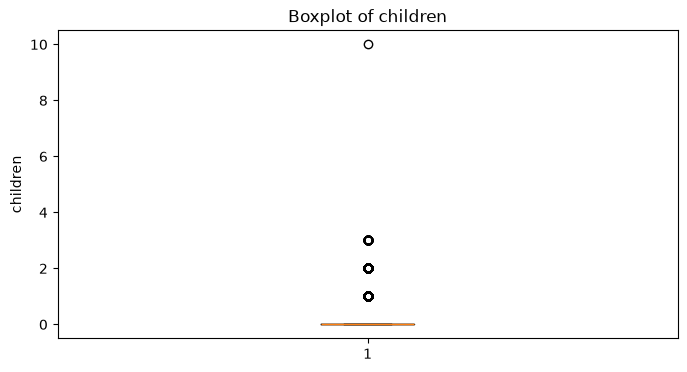

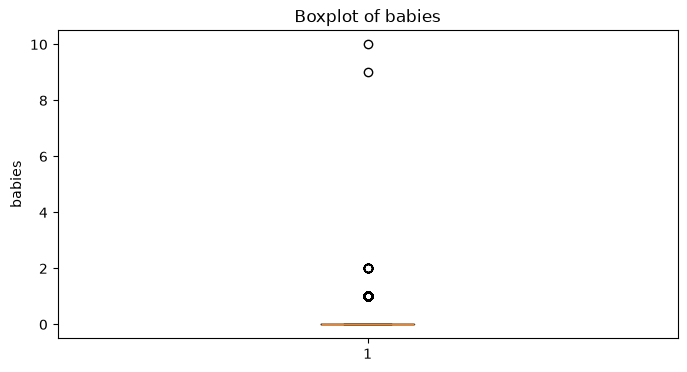

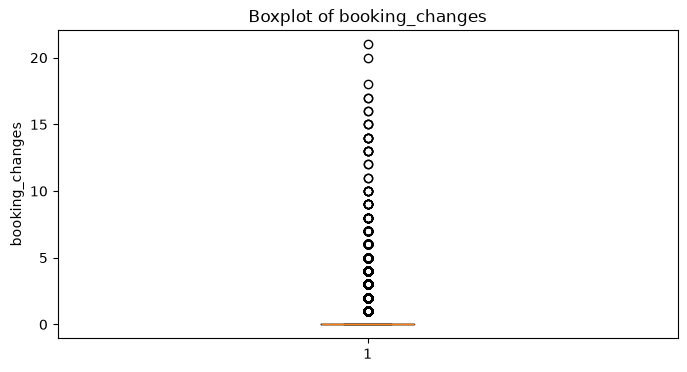

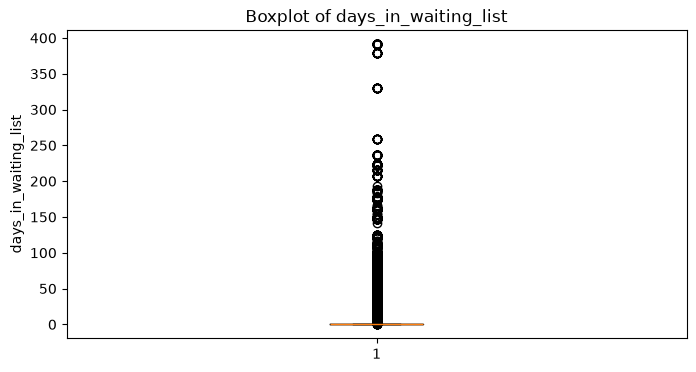

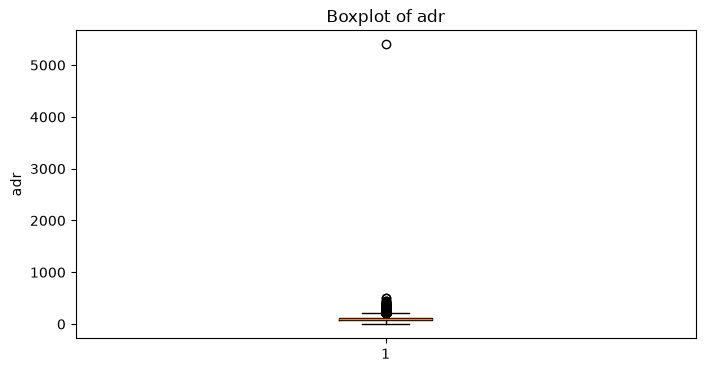

In [4]:
outlier_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "days_in_waiting_list",
    "adr"
]

import matplotlib.pyplot as plt

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

Calculating IQR outliers

In [5]:
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005
1,stays_in_weekend_nights,0.00,2.0,2.00,-3.000,5.000,265
2,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354
3,adults,2.00,2.0,0.00,2.000,2.000,29710
4,children,0.00,0.0,0.00,0.000,0.000,8590
5,babies,0.00,0.0,0.00,0.000,0.000,917
6,booking_changes,0.00,0.0,0.00,0.000,0.000,18076
7,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698
8,adr,69.29,126.0,56.71,-15.775,211.065,3793


In [6]:
for col in ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "days_in_waiting_list", "adr"]:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


print("Negative ADR values:")
display(df[df["adr"] < 0][["adr", "hotel", "adults", "children", "babies"]])


lead_time
Minimum: 0
Maximum: 737

stays_in_weekend_nights
Minimum: 0
Maximum: 19

stays_in_week_nights
Minimum: 0
Maximum: 50

days_in_waiting_list
Minimum: 0
Maximum: 391

adr
Minimum: -6.38
Maximum: 5400.0
Negative ADR values:


,adr,hotel,adults,children,babies
14969,-6.38,Resort Hotel,2,0.0,0


In [7]:
outliers_to_remove = df[(df["adr"] < 0) | (df["adr"] > 1000)]

print("Rows to be removed:", len(outliers_to_remove))
display(outliers_to_remove[["adr", "hotel", "adults", "children", "babies"]])

Rows to be removed: 2


,adr,hotel,adults,children,babies
14969,-6.38,Resort Hotel,2,0.0,0
48515,5400.00,City Hotel,2,0.0,0


In [8]:
rows_before = len(df)

df = df[(df["adr"] >= 0) & (df["adr"] <= 1000)]

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Rows before outlier removal:", rows_before)
print("Rows removed:", rows_removed)
print("Rows after outlier removal:", rows_after)

Rows before outlier removal: 119390
Rows removed: 2
Rows after outlier removal: 119388


Only two clear ADR outliers were removed: one negative ADR value (-6.38), which is invalid, and one extremely high ADR value (5400), which is clearly extreme. Other IQR-flagged observations were retained because they can represent legitimate hotel booking behavior.

# Task 3 - Create Two Preprocessing Pipelines

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

X shape: (119388, 29)
y shape: (119388,)

Training data: (95510, 29)
Testing data: (23878, 29)


### Identifying Numerical and Categorical Features

In [13]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["str"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Number of numerical columns: 19
Number of categorical columns: 10


### Preprocessing pipelines

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

numerical_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numerical_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor_B = ColumnTransformer([
    ("num", numerical_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Pipeline A and Pipeline B created successfully.")

Pipeline A and Pipeline B created successfully.


## Part B - Model Training and Performance Evaluation
### Task 4 - Train Two Classification Models

#### Training Models

In [17]:
from sklearn.linear_model import LogisticRegression
logistic_standard = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])
logistic_standard.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [18]:
logistic_minmax = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])
logistic_minmax.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree_standard = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])
tree_standard.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [20]:
tree_minmax = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])
tree_minmax.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

## Task 5 — Model Evaluation.

In [22]:
y_pred_logistic_standard = logistic_standard.predict(X_test)
y_pred_logistic_minmax = logistic_minmax.predict(X_test)

y_pred_tree_standard = tree_standard.predict(X_test)
y_pred_tree_minmax = tree_minmax.predict(X_test)

In [30]:
y_pred_logistic_standard_train = logistic_standard.predict(X_train)
y_pred_logistic_minmax_train = logistic_minmax.predict(X_train)

y_pred_tree_standard_train = tree_standard.predict(X_train)
y_pred_tree_minmax_train = tree_minmax.predict(X_train)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression + StandardScaler": (y_pred_logistic_standard_train, y_pred_logistic_standard),
    "Logistic Regression + MinMaxScaler":   (y_pred_logistic_minmax_train, y_pred_logistic_minmax),
    "Decision Tree + StandardScaler":       (y_pred_tree_standard_train, y_pred_tree_standard),
    "Decision Tree + MinMaxScaler":         (y_pred_tree_minmax_train, y_pred_tree_minmax)
}

for name, (y_pred_train, y_pred_test) in models.items():
    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Precision": precision_score(y_test, y_pred_test),
        "Recall": recall_score(y_test, y_pred_test),
        "F1-Score": f1_score(y_test, y_pred_test)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression + StandardScaler,0.819097,0.815437,0.803142,0.664669,0.727374
1,Logistic Regression + MinMaxScaler,0.815098,0.812128,0.801828,0.654607,0.720777
2,Decision Tree + StandardScaler,0.996273,0.859243,0.806643,0.815489,0.811042
3,Decision Tree + MinMaxScaler,0.996273,0.859494,0.806978,0.815828,0.811379


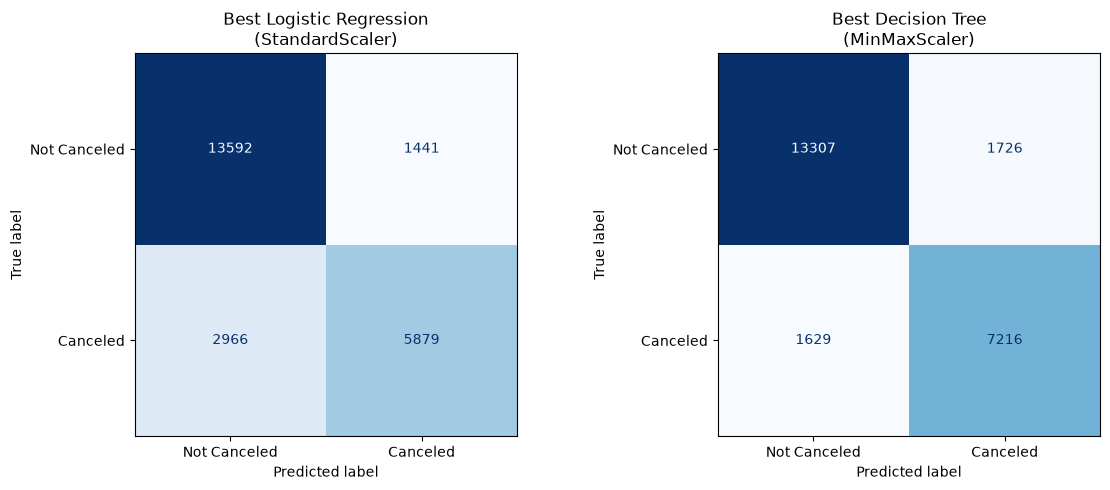

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best Logistic Regression = StandardScaler (higher accuracy/precision/F1 in your table)
cm_logistic = confusion_matrix(y_test, y_pred_logistic_standard)

# Best Decision Tree = MinMaxScaler (marginally higher across all metrics)
cm_tree = confusion_matrix(y_test, y_pred_tree_minmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=["Not Canceled", "Canceled"])
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Best Logistic Regression\n(StandardScaler)")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Not Canceled", "Canceled"])
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Best Decision Tree\n(MinMaxScaler)")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")  # for GitHub deliverable
plt.show()

## OBSERVATIONS

1. **Best overall combination:** Decision Tree + MinMaxScaler gives the best overall result 
   (Test Accuracy ≈ 0.8595, F1 ≈ 0.8114), narrowly ahead of Decision Tree + StandardScaler, 
   and clearly ahead of both Logistic Regression variants across all metrics.

2. **Scaler effect on Logistic Regression:** StandardScaler slightly outperforms MinMaxScaler 
   for Logistic Regression (Test Accuracy 0.8154 vs 0.8121, F1 0.7274 vs 0.7208). This is expected, 
   since Logistic Regression's gradient-based optimization tends to converge better with 
   standardized (zero-mean, unit-variance) features than with min-max scaled ones.

3. **Scaler effect on Decision Tree:** Scaling makes almost no difference for the Decision Tree 
   (Test Accuracy 0.8592 vs 0.8595, differing only in the 4th decimal place). This confirms that 
   tree-based models split on feature thresholds and are inherently scale-invariant.

4. **Overfitting:** Logistic Regression generalizes well (train/test gap < 1%), while the 
   Decision Tree overfits significantly (train/test gap ≈ 13.7%), since it was trained without 
   depth or leaf-size constraints.

5. **Precision vs Recall trade-off:** Decision Tree achieves noticeably higher Recall than 
   Logistic Regression (~0.815 vs ~0.65–0.66), meaning it catches far more actual cancellations, 
   which is valuable for a hotel wanting to proactively manage cancellation risk — even though 
   this comes at the cost of some overfitting.